In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import geopandas as gpd

from pygam import LogisticGAM, s, f
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# ============================================================
# 0) Carga selection JSON del MC estrella
# ============================================================
SELECTION_JSON = "/home/oisanchezp/Thesis/data/processed/seleccion_corrida_mediana_paquete_c.json"

THR_POINTS_CSV = "/home/oisanchezp/Thesis/data/processed/roc_threshold_points_paquetec_T1_P33_MC100.csv"
OUT_MODEL_PKL  = "/home/oisanchezp/Thesis/data/processed/gam_operativo_paquetec.pkl"
OUT_BUNDLE_JSON= "/home/oisanchezp/Thesis/data/processed/gam_bundle_paquetec.json"

H1 = 24

# ============================================================
# 1) Utilidades lluvia (igual a tu código)
# ============================================================
COV_NAMES = {
    0: "Cultivos",
    1: "Bosque Fragmentado",
    2: "Canteras",
    3: "Pastos",
    4: "Cuerpos de agua",
    5: "Pastos Arbolados",
    6: "Pastos Enmalezados",
    7: "Tejido Urbano Continuo",
    8: "Tejido Urbano Discontinuo",
    9: "Bosque Plantado",
}

def normalize_cobertura(s):
    # s puede venir como 1., "1.0", "Pastos", etc.
    s_num = pd.to_numeric(s, errors="coerce").astype("Int64")
    s_name = s_num.map(COV_NAMES)

    # si ya venía en texto (no numérico), lo preservamos:
    s_txt = s.astype(str).str.strip()
    out = s_name.copy()
    out[out.isna() & s.notna()] = s_txt[out.isna() & s.notna()]

    # normaliza strings raros tipo "nan"
    out = out.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return out


def load_hourly_cumsum_for_gauge(cod, ruta_series):
    fn = f"H_Datos_Procesados_Est_{cod}.csv"
    path = os.path.join(ruta_series, fn)
    if not os.path.exists(path):
        return None

    df = pd.read_csv(path, usecols=["Fecha", "P"], parse_dates=["Fecha"])
    serie_h = (df.groupby("Fecha")["P"].sum()
                 .sort_index()
                 .asfreq("H", fill_value=0.0))
    return serie_h.cumsum().astype(np.float32)

def compute_Rk_at_time(cs, tstamp, k_days):
    if cs is None or cs.empty:
        return np.nan
    t = pd.Timestamp(tstamp).floor("H")
    try:
        pos = cs.index.get_loc(t)
    except KeyError:
        loc = cs.index.get_indexer([t], method="pad")
        pos = int(loc[0])
        if pos < 0:
            return np.nan

    lag = k_days * H1
    if pos - lag < 0:
        return np.nan
    return float(cs.iloc[pos] - cs.iloc[pos - lag])

def add_rain_columns_from_cache(df, gauge_col, date_col, cache_cs, k_list):
    df = df.copy()
    for k in k_list:
        df[f"{k}d"] = np.nan

    for cod, idxs in df.groupby(gauge_col).groups.items():
        cod = int(cod) if pd.notna(cod) else cod
        if pd.isna(cod):
            continue
        cs = cache_cs.get(cod)
        if cs is None:
            continue
        for i in idxs:
            tstamp = df.at[i, date_col]
            for k in k_list:
                df.at[i, f"{k}d"] = compute_Rk_at_time(cs, tstamp, k)
    return df

def read_pluvios_as_gdf(pluv_meta_csv, target_crs):
    pl = pd.read_csv(pluv_meta_csv)
    pl["FechaInstalacion"] = pd.to_datetime(pl["FechaInstalacion"], errors="coerce")
    gpl = gpd.GeoDataFrame(
        pl,
        geometry=gpd.points_from_xy(pl["Longitude"], pl["Latitude"]),
        crs="EPSG:4326"
    ).to_crs(target_crs)
    return gpl[["Codigo", "FechaInstalacion", "geometry"]].copy()

def build_excluded_dates(su_si_dates, excl_days):
    return pd.Index(
        np.unique(
            np.concatenate([
                pd.date_range(d.normalize() - pd.Timedelta(days=excl_days),
                              d.normalize() + pd.Timedelta(days=excl_days),
                              freq="D").date
                for d in pd.to_datetime(su_si_dates).dropna()
            ])
        )
    )

def build_gauge_pool(pluv_meta_csv, ruta_series, excluded_dates,
                     umbral_1d, umbral_7d, umbral_90d,
                     min_days_after_install):
    pl = pd.read_csv(pluv_meta_csv)
    pl["FechaInstalacion"] = pd.to_datetime(pl["FechaInstalacion"], errors="coerce")

    cache_cs = {}
    candidates = {}

    H7  = 7 * 24
    H90 = 90 * 24
    H1_ = 24

    for _, row in pl.iterrows():
        cod = row["Codigo"]
        inst = row["FechaInstalacion"]

        cs = load_hourly_cumsum_for_gauge(cod, ruta_series)
        if cs is None or cs.empty:
            continue

        cache_cs[int(cod)] = cs
        idx = cs.index

        ll_1d  = cs - cs.shift(H1_)
        ll_7d  = cs - cs.shift(H7)
        ll_90d = cs - cs.shift(H90)

        ok = (ll_1d >= umbral_1d) & (ll_7d >= umbral_7d) & (ll_90d >= umbral_90d)
        ok = ok & (~pd.Index(idx.normalize().date).isin(excluded_dates))

        if pd.notna(inst):
            ok = ok & (idx >= (inst + pd.Timedelta(days=min_days_after_install)))

        cand = idx[ok.fillna(False)]
        if len(cand) > 0:
            candidates[int(cod)] = cand

    return cache_cs, candidates

def assign_nearest_gauge_with_candidates(su_gdf, gpl, candidates_by_gauge):
    su_gdf = su_gdf.copy()
    gpl = gpl[gpl["Codigo"].astype(int).isin(set(candidates_by_gauge.keys()))].copy()
    if gpl.empty:
        su_gdf["Codigo_pluvio"] = np.nan
        return su_gdf

    chosen = []
    gpl_geom = gpl.geometry
    for geom in su_gdf.geometry:
        if geom is None or geom.is_empty:
            chosen.append(np.nan); continue
        dists = gpl_geom.distance(geom)
        j = int(dists.idxmin())
        chosen.append(int(gpl.loc[j, "Codigo"]))
    su_gdf["Codigo_pluvio"] = chosen
    return su_gdf

# ============================================================
# 2) Reconstruir df_mc del MC estrella (idéntico a tu lógica)
# ============================================================
def construir_df_mc(seed, paths, params):
    rng = np.random.default_rng(seed)

    su = gpd.read_file(paths["path_gpkg"], layer=paths["layer_in"])
    if "fid" not in su.columns:
        su = su.reset_index().rename(columns={"index": "fid"})
    su["fecha_hora_evento"] = pd.to_datetime(su["fecha_hora_evento"], errors="coerce")

    if su.crs is None:
        raise ValueError("Layer sin CRS.")
    if su.crs.is_geographic:
        su = su.to_crs("EPSG:3116")
    target_crs = su.crs

    su_si = su[su["si_no"] == 1].copy()
    su_no = su[su["si_no"] == 0].copy()
    if len(su_si) == 0:
        raise ValueError("No hay SI.")

    excluidas = build_excluded_dates(su_si["fecha_hora_evento"], excl_days=params["excl_days"])

    buffer_union = su_si.geometry.buffer(params["min_dist_m"]).unary_union
    su_no_eligible = su_no[~su_no.geometry.intersects(buffer_union)].copy()

    n_si = len(su_si)
    n_no_target = 2 * n_si
    if len(su_no_eligible) < n_no_target:
        raise ValueError("No hay suficientes NO elegibles.")

    gpl = read_pluvios_as_gdf(paths["pluv_meta"], target_crs=target_crs)

    cache_cs, candidates_by_gauge = build_gauge_pool(
        paths["pluv_meta"], paths["ruta_series"], excluidas,
        umbral_1d=params["umbrales"]["1d"],
        umbral_7d=params["umbrales"]["7d"],
        umbral_90d=params["umbrales"]["90d"],
        min_days_after_install=params["t_days"] + params["p_days"]
    )
    if len(candidates_by_gauge) == 0:
        raise ValueError("No hay candidatos lluvia.")

    oversample = min(len(su_no_eligible), int(n_no_target * 4))
    sampled_idx = rng.choice(su_no_eligible.index.values, size=oversample, replace=False)
    df_no = su_no_eligible.loc[sampled_idx].copy().reset_index(drop=True)

    df_no = assign_nearest_gauge_with_candidates(df_no, gpl, candidates_by_gauge)
    df_no = df_no.dropna(subset=["Codigo_pluvio"]).copy()
    df_no = df_no.iloc[:n_no_target].copy()
    df_no["Codigo_pluvio"] = df_no["Codigo_pluvio"].astype(int)

    fechas = []
    for cod in df_no["Codigo_pluvio"].to_numpy():
        cand = candidates_by_gauge.get(int(cod), None)
        fechas.append(pd.Timestamp(rng.choice(cand.values)))
    df_no["fecha_hora_evento"] = pd.to_datetime(fechas, errors="coerce")

    # ENSO desde ONI (como entrenamiento)
    oni = pd.read_csv(paths["oni_path"], parse_dates=["date"])
    oni["date"] = pd.to_datetime(oni["date"]).dt.normalize()
    oni_min, oni_max = oni["date"].min(), oni["date"].max()

    su_si = su_si[su_si["fecha_hora_evento"].dt.normalize().between(oni_min, oni_max)].copy()
    df_no = df_no[df_no["fecha_hora_evento"].dt.normalize().between(oni_min, oni_max)].copy()

    for dff in (su_si, df_no):
        for col in ("ONI", "ENSO"):
            if col in dff.columns:
                dff.drop(columns=[col], inplace=True)

    su_si["date"] = su_si["fecha_hora_evento"].dt.normalize()
    df_no["date"] = df_no["fecha_hora_evento"].dt.normalize()

    su_si = su_si.merge(oni[["date","ONI","ENSO"]], on="date", how="left").drop(columns=["date"])
    df_no = df_no.merge(oni[["date","ONI","ENSO"]], on="date", how="left").drop(columns=["date"])

    # asignar pluvio a SI (serie disponible)
    gpl_with_series = gpl[gpl["Codigo"].astype(int).isin(set(cache_cs.keys()))].copy()
    if gpl_with_series.empty:
        raise ValueError("No hay series pluvios.")

    # más cercano (sin filigrana de instalación para simplificar; igual que tu idea)
    codes = []
    ggeom = gpl_with_series.geometry
    for geom in su_si.geometry:
        dists = ggeom.distance(geom)
        j = int(dists.idxmin())
        codes.append(int(gpl_with_series.loc[j,"Codigo"]))
    su_si["Codigo_pluvio"] = codes
    su_si["Codigo_pluvio"] = su_si["Codigo_pluvio"].astype(int)

    # lluvia features
    t_days = params["t_days"]
    p_days = params["p_days"]
    total_days = t_days + p_days
    k_list = sorted(list(set([t_days, total_days])))

    su_si = add_rain_columns_from_cache(su_si, "Codigo_pluvio", "fecha_hora_evento", cache_cs, k_list)
    df_no = add_rain_columns_from_cache(df_no, "Codigo_pluvio", "fecha_hora_evento", cache_cs, k_list)

    enso_map = {"La Niña": 0, "Neutro": 1, "El Niño": 2}
    for dff in (su_si, df_no):
        dff["DoY"] = dff["fecha_hora_evento"].dt.dayofyear
        dff["ENSO"] = dff["ENSO"].astype(str).str.strip().replace({"Neutral":"Neutro"})
        dff["ENSO_code"] = dff["ENSO"].map(enso_map).astype("Int64")
        doy_rad = 2*np.pi*(dff["DoY"]-1)/365.0
        dff["sin_doy"] = np.sin(doy_rad)
        dff["cos_doy"] = np.cos(doy_rad)

    su_si["si_no"] = 1
    df_no["si_no"] = 0
    df_mc = pd.concat([su_si, df_no], ignore_index=True)

    needed = ["si_no","ENSO_code","sin_doy","cos_doy",
              f"{t_days}d", f"{total_days}d",
              "geologia","cobertura","slope_mean","area"]
    df_mc = df_mc.dropna(subset=needed).copy()
    df_mc["si_no"] = df_mc["si_no"].astype(int)
    df_mc["ENSO_code"] = df_mc["ENSO_code"].astype(int)

    return df_mc

# ============================================================
# 3) Construir X_gam “con niveles fijos” (y guardar niveles)
# ============================================================
FEATURE_ORDER = ["T","P","sin_doy","cos_doy","ENSO","slope_mean","log_area","geologia","cobertura"]

def build_X_gam_with_levels(df, t_days, p_days, geo_levels=None, cov_levels=None):
    total_days = t_days + p_days
    col_T   = f"{t_days}d"
    col_tot = f"{total_days}d"

    T_vals = df[col_T].to_numpy(float)
    P_vals = df[col_tot].to_numpy(float) - df[col_T].to_numpy(float)

    sin_doy = df["sin_doy"].to_numpy(float)
    cos_doy = df["cos_doy"].to_numpy(float)

    slope = df["slope_mean"].to_numpy(float)
    log_area = np.log1p(df["area"].to_numpy(float))

    # ENSO factor (0/1/2) como strings para fijar niveles
    enso_cat = pd.Categorical(df["ENSO_code"].astype(int).astype(str), categories=["0","1","2"])
    enso_code = enso_cat.codes

    # niveles de geologia/cobertura
    if geo_levels is None:
        geo_levels = sorted(pd.Series(df["geologia"].astype(str)).unique().tolist())
    if cov_levels is None:
        cov_levels = sorted(pd.Series(df["cobertura"].astype(str)).unique().tolist())

    geo_cat = pd.Categorical(df["geologia"].astype(str), categories=geo_levels)
    cov_cat = pd.Categorical(df["cobertura"].astype(str), categories=cov_levels)

    # chequeo estricto: no permitir -1
    bad_geo = df.loc[geo_cat.codes < 0, "geologia"].astype(str).unique()
    bad_cov = df.loc[cov_cat.codes < 0, "cobertura"].astype(str).unique()
    if len(bad_geo) or len(bad_cov):
        raise ValueError(f"Categorías fuera de niveles. geologia={bad_geo}, cobertura={bad_cov}")

    X_gam = np.column_stack([
        T_vals, P_vals, sin_doy, cos_doy,
        enso_code, slope, log_area,
        geo_cat.codes, cov_cat.codes
    ]).astype(float)

    y = df["si_no"].to_numpy(int)
    return X_gam, y, geo_levels, cov_levels

# ============================================================
# 4) GAM + selección lambda + guardado
# ============================================================
terms = (
    s(0, n_splines=6) +   # T
    s(1, n_splines=6) +   # P
    s(2, n_splines=6) +   # sin_doy
    s(3, n_splines=6) +   # cos_doy
    f(4) +                # ENSO
    s(5, n_splines=6) +   # slope_mean
    s(6, n_splines=6) +   # log_area
    f(7) +                # geologia
    f(8)                  # cobertura
)
lam_grid = np.logspace(0, 3, 5)

def get_best_lambda_train_only(X, y, random_state=42):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=random_state
    )
    best_lam, best_auc = lam_grid[0], -np.inf
    for lam in lam_grid:
        gam = LogisticGAM(terms, lam=lam).fit(X_tr, y_tr)
        auc = roc_auc_score(y_val, gam.predict_proba(X_val))
        if auc > best_auc:
            best_auc, best_lam = auc, lam
    return float(best_lam)

def median_thresholds_from_thr_csv(thr_csv, modelo="GAM"):
    thr_df = pd.read_csv(thr_csv)
    sub = thr_df[thr_df["modelo"] == modelo].copy()
    want = ["OPT", "TPR95", "TNR95"]
    out = {}
    for name in want:
        g = sub[sub["name"] == name]
        if len(g) == 0:
            raise ValueError(f"No encontré punto {name} en {thr_csv}")
        out[name] = float(np.median(g["threshold"].to_numpy()))
    # sanity: deberían venir ordenados TPR95 <= OPT <= TNR95
    return out

def main():
    with open(SELECTION_JSON, "r") as f:
        sel = json.load(f)

    paths = sel["paths"]
    params = {
        "t_days": sel["t_days"],
        "p_days": sel["p_days"],
        "min_dist_m": sel["min_dist_m"],
        "excl_days": sel["excl_days"],
        "umbrales": sel["umbrales"],
    }
    seed_star = int(sel["seed_star"])

    df_mc = construir_df_mc(seed_star, paths, params)

    df_mc["geologia"]  = df_mc["geologia"].astype(str).str.strip()
    df_mc["cobertura"] = normalize_cobertura(df_mc["cobertura"])

    df_mc = df_mc.dropna(subset=["geologia", "cobertura"]).copy()


    # X con niveles fijos (se derivan de df_mc aquí mismo)
    X, y, geo_levels, cov_levels = build_X_gam_with_levels(
        df_mc, params["t_days"], params["p_days"]
    )

    best_lam = get_best_lambda_train_only(X, y, random_state=int(sel["random_state_split"]))
    gam = LogisticGAM(terms, lam=best_lam).fit(X, y)

    thr_prob = median_thresholds_from_thr_csv(THR_POINTS_CSV, modelo="GAM")

    bundle = {
        "t_days": params["t_days"],
        "p_days": params["p_days"],
        "feature_order": FEATURE_ORDER,
        "geo_levels": geo_levels,
        "cov_levels": cov_levels,
        "enso_levels": ["0","1","2"],
        "best_lam": best_lam,
        "thresholds_prob": thr_prob,  # {"TNR95":..., "OPT":..., "TPR95":...}
        "paths_training": paths,
        "selection": sel
    }

    with open(OUT_MODEL_PKL, "wb") as f:
        pickle.dump(gam, f)

    with open(OUT_BUNDLE_JSON, "w") as f:
        json.dump(bundle, f, indent=2, ensure_ascii=False)

    print("OK ->", OUT_MODEL_PKL)
    print("OK ->", OUT_BUNDLE_JSON)
    print("Umbrales prob:", thr_prob)
    print("Niveles geologia:", len(geo_levels), "| cobertura:", len(cov_levels))

if __name__ == "__main__":
    main()


OK -> /home/oisanchezp/Thesis/data/processed/gam_operativo_paquetec.pkl
OK -> /home/oisanchezp/Thesis/data/processed/gam_bundle_paquetec.json
Umbrales prob: {'OPT': 0.4786257132672686, 'TPR95': 0.35630024202248, 'TNR95': 0.4805547188310531}
Niveles geologia: 5 | cobertura: 10


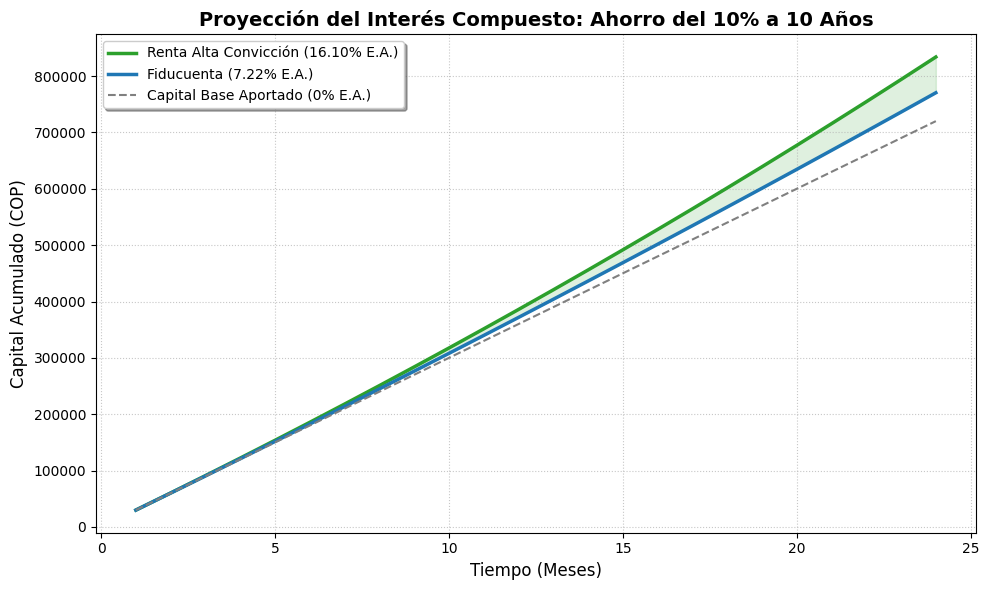

Total dinero aportado por ti: $720,000 COP
--------------------------------------------------
Capital final en Fiducuenta: $770,367 COP
Ganancia neta (Intereses): $50,367 COP
--------------------------------------------------
Capital final en Acciones: $833,820 COP
Ganancia neta (Intereses): $113,820 COP


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de Variables de Entrada
ingreso_mensual = 300000  # Reemplaza con tu salario exacto
ahorro_mensual = ingreso_mensual * 0.10
anos = 2
meses = anos * 12

# 2. Tasas de Rendimiento (Datos extraídos del informe de Bancolombia)
tasa_ea_fiducuenta = 0.0722      # 7.22% E.A.
tasa_ea_acciones = 0.1610        # 16.10% E.A.

# Conversión a Tasa Efectiva Mensual (E.M.)
tasa_em_fiducuenta = (1 + tasa_ea_fiducuenta)**(1/12) - 1
tasa_em_acciones = (1 + tasa_ea_acciones)**(1/12) - 1

# 3. Inicialización de Vectores
tiempo = np.arange(1, meses + 1)
capital_fiducuenta = np.zeros(meses)
capital_acciones = np.zeros(meses)
capital_aportado = np.zeros(meses) # Solo para ver cuánto salió de tu bolsillo

# 4. Bucle de Capitalización (El motor del interés compuesto)
for i in range(meses):
    if i == 0:
        capital_fiducuenta[i] = ahorro_mensual
        capital_acciones[i] = ahorro_mensual
        capital_aportado[i] = ahorro_mensual
    else:
        # Capital anterior + intereses del mes + nuevo aporte
        capital_fiducuenta[i] = capital_fiducuenta[i-1] * (1 + tasa_em_fiducuenta) + ahorro_mensual
        capital_acciones[i] = capital_acciones[i-1] * (1 + tasa_em_acciones) + ahorro_mensual
        capital_aportado[i] = capital_aportado[i-1] + ahorro_mensual

# 5. Visualización de la Serie Temporal
plt.figure(figsize=(10, 6))

plt.plot(tiempo, capital_acciones, label='Renta Alta Convicción (16.10% E.A.)', color='#2ca02c', linewidth=2.5)
plt.plot(tiempo, capital_fiducuenta, label='Fiducuenta (7.22% E.A.)', color='#1f77b4', linewidth=2.5)
plt.plot(tiempo, capital_aportado, label='Capital Base Aportado (0% E.A.)', color='gray', linestyle='--')

# Rellenar el área que representa el "Costo de Oportunidad"
plt.fill_between(tiempo, capital_fiducuenta, capital_acciones, color='#2ca02c', alpha=0.15)

plt.title('Proyección del Interés Compuesto: Ahorro del 10% a 10 Años', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Meses)', fontsize=12)
plt.ylabel('Capital Acumulado (COP)', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)

# Desactivar notación científica en el eje Y para mejor legibilidad
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

plt.show()

# 6. Salida de Datos Consolidados
print(f"Total dinero aportado por ti: ${capital_aportado[-1]:,.0f} COP")
print("-" * 50)
print(f"Capital final en Fiducuenta: ${capital_fiducuenta[-1]:,.0f} COP")
print(f"Ganancia neta (Intereses): ${capital_fiducuenta[-1] - capital_aportado[-1]:,.0f} COP")
print("-" * 50)
print(f"Capital final en Acciones: ${capital_acciones[-1]:,.0f} COP")
print(f"Ganancia neta (Intereses): ${capital_acciones[-1] - capital_aportado[-1]:,.0f} COP")